# Portfolio Growth Report

Читает лучшие параметры из `results/grid_search/best_by_target.csv`,  
перезапускает пайплайн и строит кривые роста ($10 000 стартовый капитал).

In [144]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from dataclasses import replace

from sarb.run import RunConfig, load_market_prices, load_run_config, run_unified_pipeline

# ── константы ───────────────────────────────────────────────────────────────
INITIAL_CAPITAL = 10_000.0
BEST_BY_TARGET_PATH = PROJECT_ROOT / "results" / "grid_search" / "best_by_target.csv"

# ── глобальный стиль графиков: белая тема, тёмный текст ─────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.grid": True,
    "grid.color": "#E5E5E5",
    "grid.linewidth": 0.7,
    "grid.alpha": 1.0,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#CCCCCC",
    "text.color": "#222222",
    "axes.labelcolor": "#333333",
    "xtick.color": "#444444",
    "ytick.color": "#444444",
    "axes.titlecolor": "#111111",
    "legend.facecolor": "white",
    "legend.edgecolor": "#DDDDDD",
    "legend.framealpha": 1.0,
    "legend.labelcolor": "#222222",
    "font.size": 10,
    "figure.dpi": 120,
})

# ── яркая палитра для линий на графиках ─────────────────────────────────────
PALETTE = [
    "#1976D2",  # синий
    "#E65100",  # оранжевый
    "#2E7D32",  # зелёный
    "#C2185B",  # малиновый
    "#6A1B9A",  # фиолетовый
    "#00838F",  # бирюзовый
    "#EF6C00",  # янтарный
    "#00695C",  # зелёно-бирюзовый
    "#B71C1C",  # красный
    "#558B2F",  # оливковый
]

# ── стиль таблиц: белый фон, тёмный текст, перенос заголовков, разделители ──
TABLE_STYLES = [
    # общие свойства
    {"selector": "", "props": [
        ("border-collapse", "collapse"),
        ("font-size", "13px"),
        ("font-family", "Arial, sans-serif"),
        ("width", "100%"),
    ]},
    # заголовки — перенос + выравнивание по низу + вертикальные разделители
    {"selector": "thead th", "props": [
        ("background-color", "#F0F4F8"),
        ("color", "#1A202C"),
        ("font-weight", "700"),
        ("border-top", "2px solid #A0AEC0"),
        ("border-bottom", "2px solid #A0AEC0"),
        ("border-right", "1px solid #CBD5E0"),
        ("padding", "10px 12px"),
        ("text-align", "left"),
        ("vertical-align", "bottom"),
        ("word-break", "break-word"),
        ("min-width", "80px"),
        ("max-width", "140px"),
        ("line-height", "1.3"),
    ]},
    # ячейки данных — вертикальный разделитель справа
    {"selector": "tbody td", "props": [
        ("background-color", "white"),
        ("color", "#1A202C"),
        ("border-bottom", "1px solid #E2E8F0"),
        ("border-right", "1px solid #E2E8F0"),
        ("padding", "8px 12px"),
        ("text-align", "left"),
        ("white-space", "nowrap"),
    ]},
    # колонка с номерами строк
    {"selector": "tbody th", "props": [
        ("background-color", "#F7FAFC"),
        ("color", "#718096"),
        ("font-weight", "normal"),
        ("border-bottom", "1px solid #E2E8F0"),
        ("border-right", "2px solid #A0AEC0"),
        ("padding", "8px 10px"),
        ("text-align", "right"),
    ]},
    # угловая ячейка заголовка (над номерами строк)
    {"selector": "thead th.blank, thead th.index_name", "props": [
        ("background-color", "#F0F4F8"),
        ("border-right", "2px solid #A0AEC0"),
    ]},
    # подсветка строки при наведении
    {"selector": "tbody tr:hover td, tbody tr:hover th", "props": [
        ("background-color", "#EBF4FF"),
    ]},
]

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/mikhailchekunov/PycharmProjects/replication-portfolio-arbitrage-mvp


## 1. Лучшие параметры из грид-сёрча

In [145]:
best_params = pd.read_csv(BEST_BY_TARGET_PATH)

preview = best_params[[
    "market", "target", "entry_z", "exit_z", "rebalance_frequency",
    "sharpe_ratio", "annualized_return", "max_drawdown", "total_return",
]].copy()
preview.index = range(1, len(preview) + 1)

(
    preview.style
    .format({
        "sharpe_ratio": "{:.3f}",
        "annualized_return": "{:+.1%}",
        "max_drawdown": "{:.1%}",
        "total_return": "{:+.1%}",
    })
    .set_table_styles(TABLE_STYLES)
    .set_caption("Лучшие параметры по таргету (отсортировано по Sharpe)")
)

,market,target,entry_z,exit_z,rebalance_frequency,sharpe_ratio,annualized_return,max_drawdown,total_return
1,crypto,ADA,3.000000,0.500000,24,2.076,+90.8%,-36.8%,+4242.7%
2,crypto,ATOM,3.000000,0.250000,24,2.539,+127.8%,-44.6%,+12105.2%
3,crypto,AVAX,2.500000,0.250000,24,2.187,+148.8%,-55.0%,+11704.4%
4,crypto,BNB,3.000000,0.250000,24,1.319,+51.2%,-53.4%,+1016.0%
5,crypto,BTC,3.000000,0.500000,24,1.210,+28.1%,-29.7%,+323.9%
6,crypto,DOGE,1.500000,0.250000,72,0.024,+3.0%,-98.8%,+19.0%
7,crypto,ETH,3.000000,0.250000,24,1.628,+52.1%,-23.0%,+1056.6%
8,crypto,LINK,1.500000,0.250000,24,1.651,+90.5%,-43.7%,+4205.0%
9,crypto,SOL,1.500000,0.500000,24,0.986,+79.7%,-69.8%,+2200.5%
10,crypto,XRP,2.000000,0.250000,24,1.405,+106.2%,-66.8%,+6727.9%


## 2. Вспомогательные функции

In [146]:
def prepare_prices(market: str, prices: pd.DataFrame) -> pd.DataFrame:
    if market == "russia":
        return prices.dropna(how="any")
    return prices


def resolve_ticker(prices: pd.DataFrame, target: str) -> str:
    if target in prices.columns:
        return target
    alt = target.replace(".", "-")
    if alt in prices.columns:
        return alt
    raise KeyError(f"Target {target!r} not found in prices")


def reconstruct_run_config(row: pd.Series) -> RunConfig:
    base = load_run_config(str(row["market"]))
    return replace(
        base,
        train_window=int(row["train_window"]),
        rebalance_frequency=int(row["rebalance_frequency"]),
        entry_z=float(row["entry_z"]),
        exit_z=float(row["exit_z"]),
    )


def run_best_pipeline(row: pd.Series, prices: pd.DataFrame):
    target = resolve_ticker(prices, str(row["target"]))
    universe = [s.strip() for s in str(row["universe_assets"]).split(",")]
    run_config = reconstruct_run_config(row)
    return run_unified_pipeline(
        prices, target=target, universe=universe, run_config=run_config,
    )


def compute_trade_stats(result) -> dict:
    """Статистика по сделкам: средний результат и % прибыльных (по сделкам, не по барам)."""
    pos = result.backtest.execution_positions.fillna(0.0)
    rets = result.backtest.strategy_returns.fillna(0.0)
    is_active = pos != 0.0
    if not is_active.any():
        return {"avg_trade": 0.0, "trade_hit_rate": 0.0}
    groups = (pos != pos.shift(fill_value=0.0)).cumsum()
    trade_rets = [
        float((1 + grp).prod() - 1)
        for _, grp in rets[is_active].groupby(groups[is_active])
    ]
    if not trade_rets:
        return {"avg_trade": 0.0, "trade_hit_rate": 0.0}
    return {
        "avg_trade": float(np.mean(trade_rets)),
        "trade_hit_rate": float(sum(1 for r in trade_rets if r > 0) / len(trade_rets)),
    }


def compute_bnh_return(result) -> float:
    """Buy & Hold доходность таргета за тот же период, что и бэктест."""
    idx = result.backtest.equity_curve.index
    prices = result.prices[result.target].reindex(idx).ffill().dropna()
    if len(prices) < 2:
        return 0.0
    return float(prices.iloc[-1] / prices.iloc[0] - 1.0)


def format_universe(universe: tuple, max_show: int = 5) -> str:
    assets = list(universe)
    shown = ", ".join(assets[:max_show])
    if len(assets) > max_show:
        shown += f" (+{len(assets) - max_show})"
    return shown


print("Функции определены.")

Функции определены.


## 3. Прогон пайплайна

⏳ USA / Russia: ~1–2 мин, Crypto: ~5–10 мин (часовые данные).

In [147]:
import time

pipeline_results = {}  # (market, target) -> UnifiedPipelineResult

for market in ["usa", "russia", "crypto"]:
    t0 = time.time()
    print(f"\n{'─'*55}")
    print(f"  {market.upper()} — загрузка цен...")
    raw_prices = load_market_prices(market)
    prices = prepare_prices(market, raw_prices)
    print(f"  Загружено: {prices.shape[0]:,} строк × {prices.shape[1]} активов")

    for _, row in best_params[best_params["market"] == market].iterrows():
        target = row["target"]
        print(f"  [{market}/{target}]... ", end="", flush=True)
        t1 = time.time()
        try:
            result = run_best_pipeline(row, prices)
            pipeline_results[(market, target)] = result
            m = result.backtest.metrics
            print(
                f"Sharpe={m.sharpe_ratio:.3f}  "
                f"Return={m.total_return*100:+.1f}%  "
                f"MDD={m.max_drawdown*100:.1f}%  "
                f"[{time.time()-t1:.1f}s]"
            )
        except Exception as exc:
            print(f"ОШИБКА: {exc}")

    print(f"  {market.upper()} готово за {time.time()-t0:.1f}s")

print(f"\n✓ Итого: {len(pipeline_results)} таргетов обработано.")


───────────────────────────────────────────────────────
  USA — загрузка цен...
  Загружено: 2,514 строк × 142 активов
  [usa/AAPL]... Sharpe=0.813  Return=+352.2%  MDD=-26.9%  [2.5s]
  [usa/AMZN]... Sharpe=0.915  Return=+470.4%  MDD=-28.9%  [0.2s]
  [usa/BRK.B]... Sharpe=1.164  Return=+100.4%  MDD=-4.1%  [1.3s]
  [usa/CAT]... Sharpe=0.892  Return=+596.2%  MDD=-31.4%  [1.3s]
  [usa/JNJ]... Sharpe=1.118  Return=+252.5%  MDD=-17.1%  [2.6s]
  [usa/JPM]... Sharpe=1.402  Return=+603.0%  MDD=-21.1%  [2.5s]
  [usa/KO]... Sharpe=0.886  Return=+70.3%  MDD=-12.2%  [2.6s]
  [usa/MSFT]... Sharpe=0.724  Return=+203.2%  MDD=-25.2%  [0.6s]
  [usa/NVDA]... Sharpe=1.244  Return=+4064.7%  MDD=-35.9%  [0.6s]
  [usa/XOM]... Sharpe=0.719  Return=+548.0%  MDD=-44.6%  [2.5s]
  USA готово за 17.2s

───────────────────────────────────────────────────────
  RUSSIA — загрузка цен...
  Загружено: 2,959 строк × 26 активов
  [russia/AFKS]... Sharpe=1.356  Return=+1150.0%  MDD=-21.0%  [2.6s]
  [russia/AFLT]... Shar

## 4. Функции визуализации

In [148]:
def plot_equity_curves(
    pipeline_results: dict,
    market: str,
    title: str,
    initial_capital: float = INITIAL_CAPITAL,
    figsize: tuple = (14, 6),
) -> plt.Figure:
    items = sorted(
        [(k, v) for k, v in pipeline_results.items() if k[0] == market],
        key=lambda x: -x[1].backtest.metrics.total_return,
    )
    if not items:
        print(f"Нет данных для {market}")
        return None

    fig, ax = plt.subplots(figsize=figsize)
    # явно форсируем белый фон на обоих уровнях
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    for i, ((mkt, target), result) in enumerate(items):
        equity = result.backtest.equity_curve * initial_capital
        m = result.backtest.metrics
        label = (
            f"{target}  |  "
            f"Прирост {m.total_return*100:+.0f}%  "
            f"Коэффициент Шарпа {m.sharpe_ratio:.2f}"
        )
        ax.plot(
            equity.index, equity,
            label=label,
            linewidth=2.0,
            color=PALETTE[i % len(PALETTE)],
        )

    ax.axhline(
        initial_capital, color="#AAAAAA", linestyle="--",
        linewidth=1.2, label=f"Старт ${initial_capital:,.0f}",
    )

    ax.set_title(title, fontsize=13, fontweight="bold", pad=14)
    ax.set_ylabel("Стоимость портфеля ($)", fontsize=10)
    ax.set_xlabel("Дата", fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())

    for spine in ax.spines.values():
        spine.set_edgecolor("#CCCCCC")

    legend = ax.legend(
        loc="upper left", fontsize=8.5,
        frameon=True, borderpad=0.8, labelspacing=0.5,
    )
    legend.get_frame().set_facecolor("white")
    legend.get_frame().set_edgecolor("#DDDDDD")

    fig.tight_layout()
    return fig

In [149]:
def build_metrics_table(pipeline_results: dict, market: str) -> pd.io.formats.style.Styler:
    rows = []
    for (mkt, target), result in sorted(
        pipeline_results.items(),
        key=lambda x: -x[1].backtest.metrics.sharpe_ratio,
    ):
        if mkt != market:
            continue

        m = result.backtest.metrics
        rc = result.run_config
        equity = result.backtest.equity_curve * INITIAL_CAPITAL
        ts = compute_trade_stats(result)

        rows.append({
            "Актив": target,
            "Стартовый капитал": INITIAL_CAPITAL,
            "Финальный капитал": equity.iloc[-1],
            "Общий прирост": m.total_return,
            "Buy & Hold": compute_bnh_return(result),
            "Среднегеометрический годовой прирост": m.annualized_return,
            "Количество сделок": m.number_of_trades,
            "Средний результат по сделке": ts["avg_trade"],
            "Процент прибыльных сделок": ts["trade_hit_rate"],
            "Максимальная просадка": m.max_drawdown,
            "Коэффициент Шарпа": m.sharpe_ratio,
            "z-score (вход/выход)": f"{rc.entry_z} / {rc.exit_z}",
        })

    df = pd.DataFrame(rows)
    df.index = range(1, len(df) + 1)

    return (
        df.style
        .format({
            "Стартовый капитал": "${:,.0f}",
            "Финальный капитал": "${:,.0f}",
            "Общий прирост": "{:+.1%}",
            "Buy & Hold": "{:+.1%}",
            "Среднегеометрический годовой прирост": "{:+.1%}",
            "Средний результат по сделке": "{:+.2%}",
            "Процент прибыльных сделок": "{:.1%}",
            "Максимальная просадка": "{:.1%}",
            "Коэффициент Шарпа": "{:.3f}",
        })
        .set_table_styles(TABLE_STYLES)
    )

---
## 5. США (USA Market)

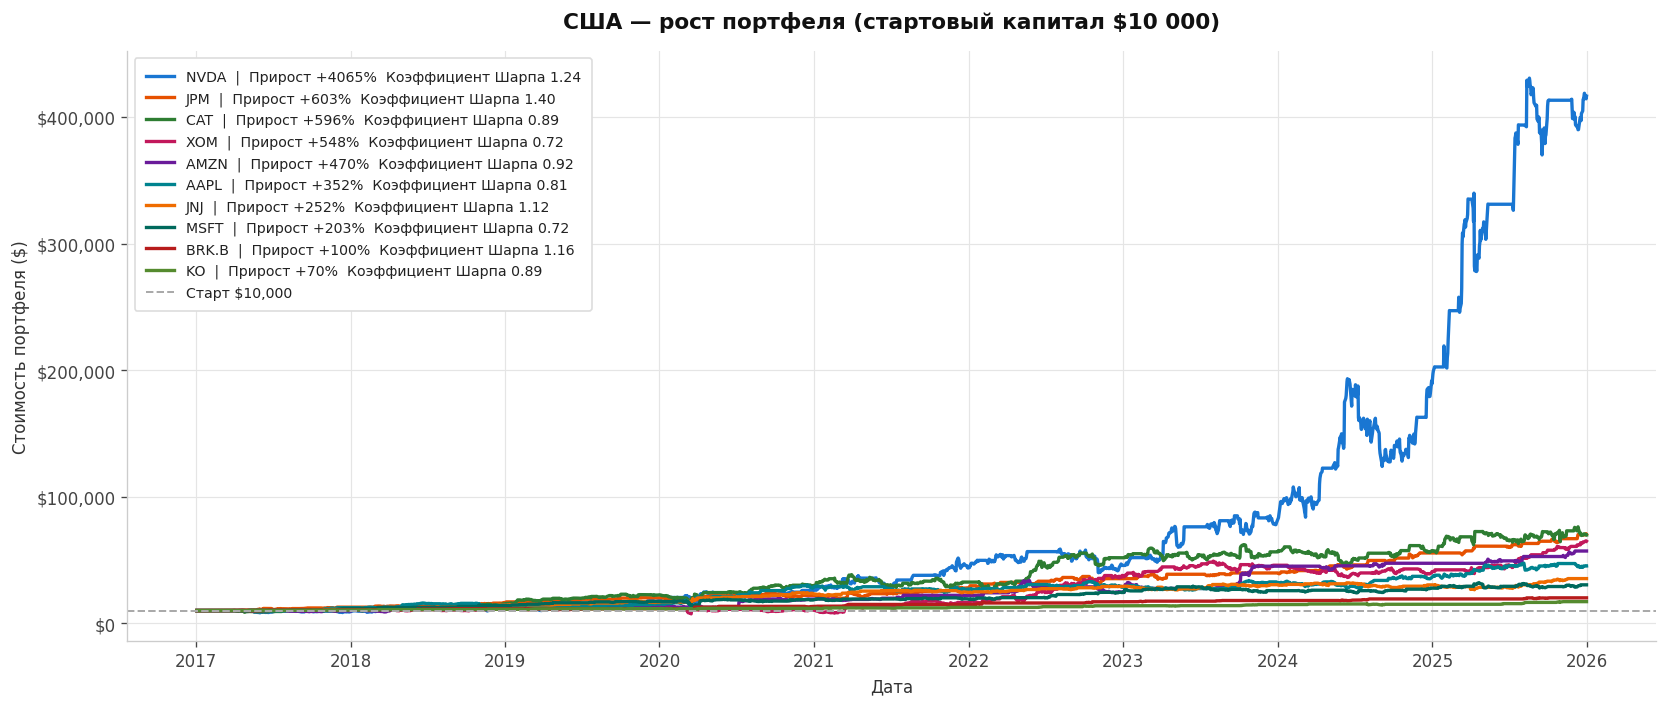

In [150]:
fig = plot_equity_curves(
    pipeline_results, "usa",
    "США — рост портфеля (стартовый капитал $10 000)",
)
plt.show()

In [151]:
build_metrics_table(pipeline_results, "usa")

,Актив,Стартовый капитал,Финальный капитал,Общий прирост,Buy & Hold,Среднегеометрический годовой прирост,Количество сделок,Средний результат по сделке,Процент прибыльных сделок,Максимальная просадка,Коэффициент Шарпа,z-score (вход/выход)
1,JPM,"$10,000","$70,297",+603.0%,+370.3%,+24.3%,128,+3.10%,89.4%,-21.1%,1.402,1.5 / 0.5
2,NVDA,"$10,000","$416,468",+4064.7%,+7323.8%,+51.5%,105,+6.90%,78.3%,-35.9%,1.244,1.5 / 0.25
3,BRK.B,"$10,000","$20,041",+100.4%,+206.8%,+8.1%,32,+4.54%,100.0%,-4.1%,1.164,3.0 / 0.75
4,JNJ,"$10,000","$35,246",+252.5%,+129.2%,+15.1%,154,+1.70%,84.8%,-17.1%,1.118,1.5 / 0.75
5,AMZN,"$10,000","$57,042",+470.4%,+512.5%,+21.4%,41,+8.84%,77.3%,-28.9%,0.915,3.0 / 0.25
6,CAT,"$10,000","$69,623",+596.2%,+647.8%,+24.1%,142,+2.73%,73.1%,-31.4%,0.892,1.0 / 0.25
7,KO,"$10,000","$17,029",+70.3%,+121.8%,+6.1%,48,+2.31%,87.5%,-12.2%,0.886,3.0 / 0.75
8,AAPL,"$10,000","$45,221",+352.2%,+915.5%,+18.3%,107,+2.77%,74.6%,-26.9%,0.813,1.5 / 0.25
9,MSFT,"$10,000","$30,318",+203.2%,+759.0%,+13.2%,95,+2.39%,83.7%,-25.2%,0.724,2.0 / 0.5
10,XOM,"$10,000","$64,803",+548.0%,+98.2%,+23.2%,138,+2.84%,78.4%,-44.6%,0.719,1.0 / 0.25


---
## 6. Россия (Russia Market)

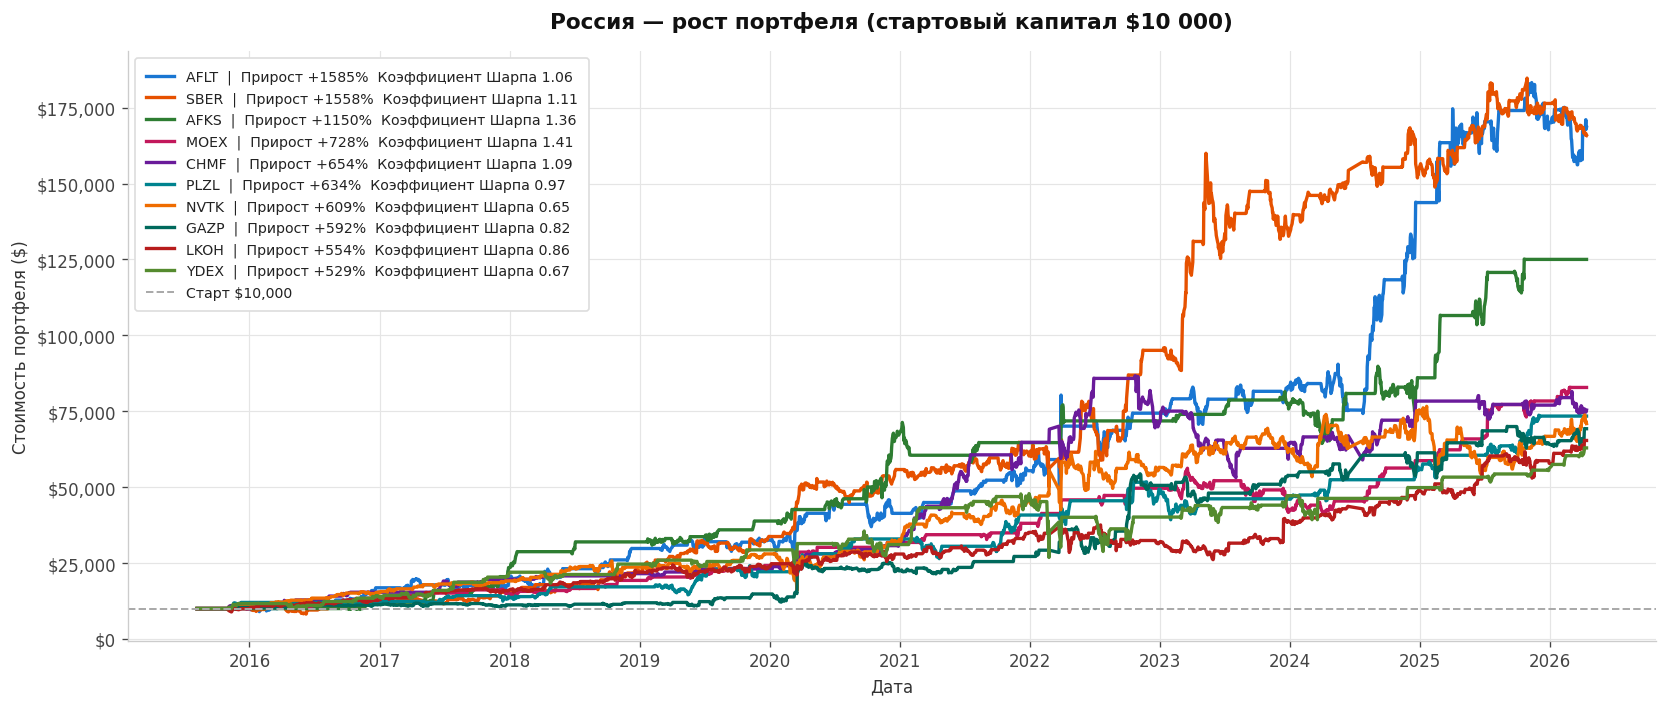

In [152]:
fig = plot_equity_curves(
    pipeline_results, "russia",
    "Россия — рост портфеля (стартовый капитал $10 000)",
)
plt.show()

In [153]:
build_metrics_table(pipeline_results, "russia")

,Актив,Стартовый капитал,Финальный капитал,Общий прирост,Buy & Hold,Среднегеометрический годовой прирост,Количество сделок,Средний результат по сделке,Процент прибыльных сделок,Максимальная просадка,Коэффициент Шарпа,z-score (вход/выход)
1,MOEX,"$10,000","$82,827",+728.3%,+127.9%,+21.8%,90,+4.91%,91.3%,-27.7%,1.407,2.5 / 0.5
2,AFKS,"$10,000","$125,002",+1150.0%,-43.4%,+26.5%,53,+10.30%,96.3%,-21.0%,1.356,3.0 / 0.25
3,SBER,"$10,000","$165,795",+1557.9%,+327.9%,+29.9%,173,+3.18%,80.4%,-26.9%,1.111,1.0 / 0.25
4,CHMF,"$10,000","$75,384",+653.8%,+19.8%,+20.7%,70,+5.86%,81.6%,-38.7%,1.092,2.5 / 0.25
5,AFLT,"$10,000","$168,530",+1585.3%,+18.9%,+30.1%,93,+6.20%,85.7%,-25.6%,1.059,2.0 / 0.25
6,PLZL,"$10,000","$73,394",+633.9%,+972.2%,+20.4%,53,+7.80%,85.7%,-24.2%,0.970,3.0 / 0.25
7,LKOH,"$10,000","$65,364",+553.6%,+115.4%,+19.1%,226,+1.76%,79.7%,-30.5%,0.865,1.0 / 0.5
8,GAZP,"$10,000","$69,235",+592.4%,-9.5%,+19.7%,105,+4.13%,79.6%,-23.6%,0.820,2.0 / 0.5
9,YDEX,"$10,000","$62,909",+529.1%,+386.1%,+18.7%,77,+5.19%,76.9%,-43.9%,0.671,2.5 / 0.5
10,NVTK,"$10,000","$70,919",+609.2%,+99.8%,+20.0%,155,+2.60%,80.5%,-43.6%,0.653,1.5 / 0.25


---
## 7. Крипто (Crypto Market)

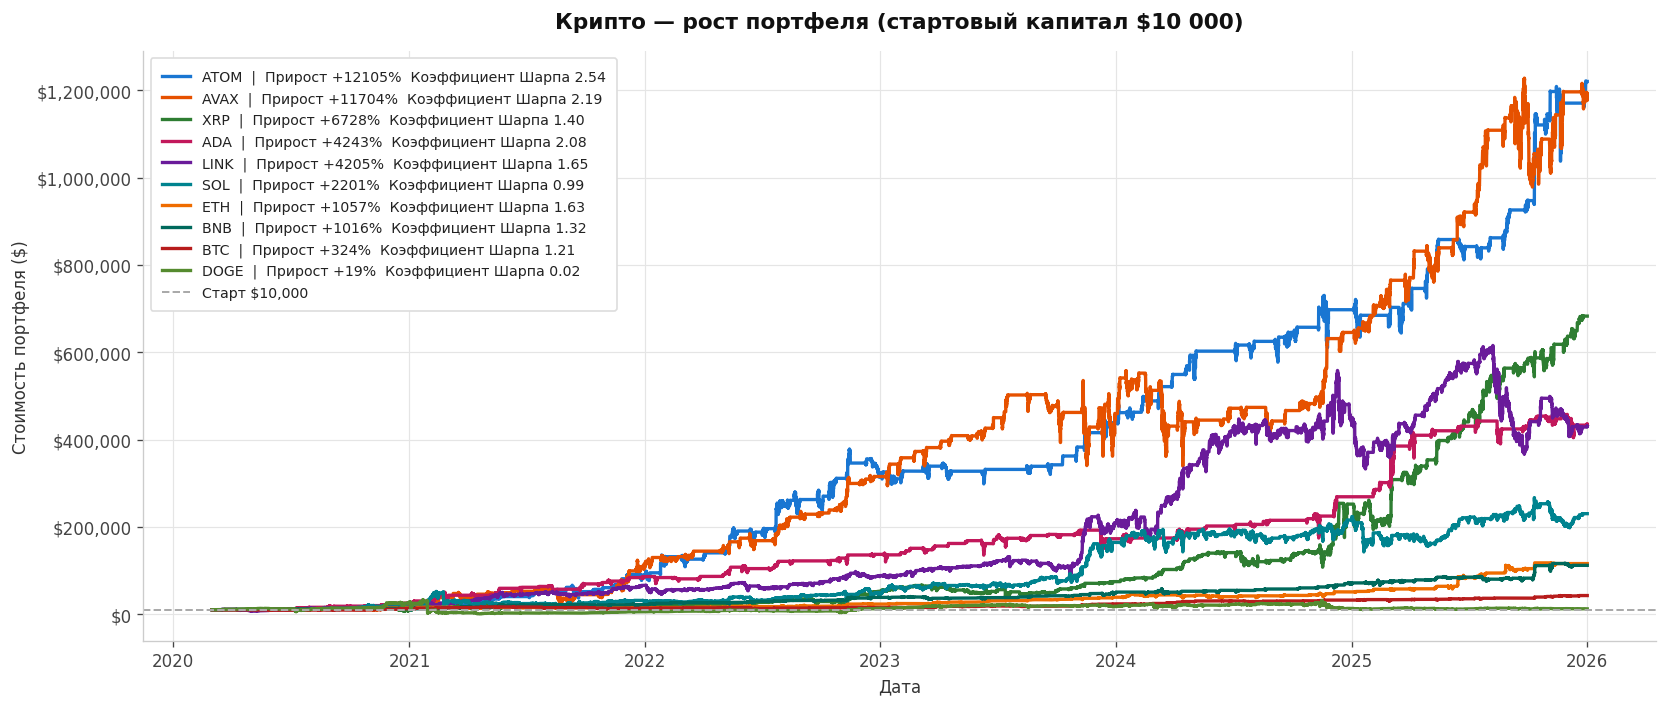

In [154]:
fig = plot_equity_curves(
    pipeline_results, "crypto",
    "Крипто — рост портфеля (стартовый капитал $10 000)",
)
plt.show()

In [155]:
build_metrics_table(pipeline_results, "crypto")

,Актив,Стартовый капитал,Финальный капитал,Общий прирост,Buy & Hold,Среднегеометрический годовой прирост,Количество сделок,Средний результат по сделке,Процент прибыльных сделок,Максимальная просадка,Коэффициент Шарпа,z-score (вход/выход)
1,ATOM,"$10,000","$1,220,524",+12105.2%,-44.1%,+127.8%,200,+5.23%,84.2%,-44.6%,2.539,3.0 / 0.25
2,AVAX,"$10,000","$1,180,438",+11704.4%,+271.8%,+148.8%,263,+4.19%,81.2%,-55.0%,2.187,2.5 / 0.25
3,ADA,"$10,000","$434,266",+4242.7%,+604.7%,+90.8%,200,+4.05%,79.4%,-36.8%,2.076,3.0 / 0.5
4,LINK,"$10,000","$430,499",+4205.0%,+204.3%,+90.5%,560,+1.56%,78.7%,-43.7%,1.651,1.5 / 0.25
5,ETH,"$10,000","$115,658",+1056.6%,+1250.5%,+52.1%,179,+2.97%,83.5%,-23.0%,1.628,3.0 / 0.25
6,XRP,"$10,000","$682,789",+6727.9%,+690.4%,+106.2%,419,+2.45%,78.5%,-66.8%,1.405,2.0 / 0.25
7,BNB,"$10,000","$111,602",+1016.0%,+4379.9%,+51.2%,192,+2.84%,82.3%,-53.4%,1.319,3.0 / 0.25
8,BTC,"$10,000","$42,392",+323.9%,+926.1%,+28.1%,180,+1.80%,76.7%,-29.7%,1.210,3.0 / 0.5
9,SOL,"$10,000","$230,050",+2200.5%,+3473.8%,+79.7%,542,+1.49%,71.4%,-69.8%,0.986,1.5 / 0.5
10,DOGE,"$10,000","$11,902",+19.0%,+5122.2%,+3.0%,497,+0.86%,70.4%,-98.8%,0.024,1.5 / 0.25


---
## 8. Сводная таблица — все рынки

In [156]:
all_rows = []
for (market, target), result in sorted(
    pipeline_results.items(),
    key=lambda x: (x[0][0], -x[1].backtest.metrics.sharpe_ratio),
):
    m = result.backtest.metrics
    rc = result.run_config
    equity = result.backtest.equity_curve * INITIAL_CAPITAL
    ts = compute_trade_stats(result)

    all_rows.append({
        "Рынок": market.upper(),
        "Актив": target,
        "Стартовый капитал": INITIAL_CAPITAL,
        "Финальный капитал": equity.iloc[-1],
        "Общий прирост": m.total_return,
        "Buy & Hold": compute_bnh_return(result),
        "Среднегеометрический годовой прирост": m.annualized_return,
        "Количество сделок": m.number_of_trades,
        "Средний результат по сделке": ts["avg_trade"],
        "Процент прибыльных сделок": ts["trade_hit_rate"],
        "Максимальная просадка": m.max_drawdown,
        "Коэффициент Шарпа": m.sharpe_ratio,
        "z-score (вход/выход)": f"{rc.entry_z} / {rc.exit_z}",
    })

summary_df = pd.DataFrame(all_rows)
summary_df.index = range(1, len(summary_df) + 1)

(
    summary_df.style
    .format({
        "Стартовый капитал": "${:,.0f}",
        "Финальный капитал": "${:,.0f}",
        "Общий прирост": "{:+.1%}",
        "Buy & Hold": "{:+.1%}",
        "Среднегеометрический годовой прирост": "{:+.1%}",
        "Средний результат по сделке": "{:+.2%}",
        "Процент прибыльных сделок": "{:.1%}",
        "Максимальная просадка": "{:.1%}",
        "Коэффициент Шарпа": "{:.3f}",
    })
    .set_table_styles(TABLE_STYLES)
    .set_caption("Все рынки и таргеты")
)

,Рынок,Актив,Стартовый капитал,Финальный капитал,Общий прирост,Buy & Hold,Среднегеометрический годовой прирост,Количество сделок,Средний результат по сделке,Процент прибыльных сделок,Максимальная просадка,Коэффициент Шарпа,z-score (вход/выход)
1,CRYPTO,ATOM,"$10,000","$1,220,524",+12105.2%,-44.1%,+127.8%,200,+5.23%,84.2%,-44.6%,2.539,3.0 / 0.25
2,CRYPTO,AVAX,"$10,000","$1,180,438",+11704.4%,+271.8%,+148.8%,263,+4.19%,81.2%,-55.0%,2.187,2.5 / 0.25
3,CRYPTO,ADA,"$10,000","$434,266",+4242.7%,+604.7%,+90.8%,200,+4.05%,79.4%,-36.8%,2.076,3.0 / 0.5
4,CRYPTO,LINK,"$10,000","$430,499",+4205.0%,+204.3%,+90.5%,560,+1.56%,78.7%,-43.7%,1.651,1.5 / 0.25
5,CRYPTO,ETH,"$10,000","$115,658",+1056.6%,+1250.5%,+52.1%,179,+2.97%,83.5%,-23.0%,1.628,3.0 / 0.25
6,CRYPTO,XRP,"$10,000","$682,789",+6727.9%,+690.4%,+106.2%,419,+2.45%,78.5%,-66.8%,1.405,2.0 / 0.25
7,CRYPTO,BNB,"$10,000","$111,602",+1016.0%,+4379.9%,+51.2%,192,+2.84%,82.3%,-53.4%,1.319,3.0 / 0.25
8,CRYPTO,BTC,"$10,000","$42,392",+323.9%,+926.1%,+28.1%,180,+1.80%,76.7%,-29.7%,1.210,3.0 / 0.5
9,CRYPTO,SOL,"$10,000","$230,050",+2200.5%,+3473.8%,+79.7%,542,+1.49%,71.4%,-69.8%,0.986,1.5 / 0.5
10,CRYPTO,DOGE,"$10,000","$11,902",+19.0%,+5122.2%,+3.0%,497,+0.86%,70.4%,-98.8%,0.024,1.5 / 0.25


---
## 9. Сравнение: лучший таргет с каждого рынка

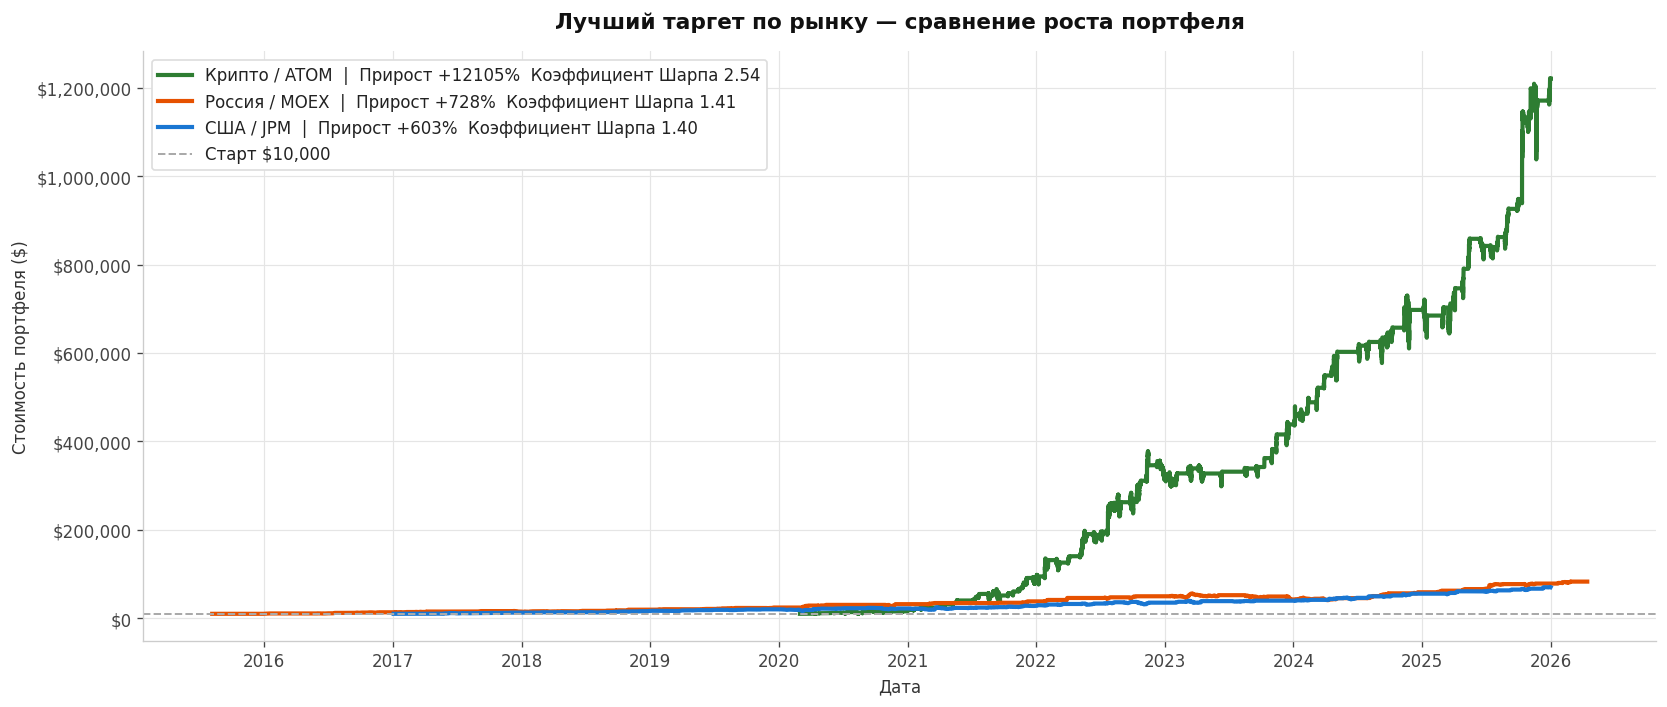

In [157]:
MARKET_COLORS = {"usa": "#1976D2", "russia": "#E65100", "crypto": "#2E7D32"}
MARKET_LABELS = {"usa": "США", "russia": "Россия", "crypto": "Крипто"}

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

best_per_market = []
for market in ["usa", "russia", "crypto"]:
    candidates = [(k, v) for k, v in pipeline_results.items() if k[0] == market]
    if not candidates:
        continue
    (_, target), result = max(candidates, key=lambda x: x[1].backtest.metrics.sharpe_ratio)
    best_per_market.append((market, target, result))

best_per_market.sort(key=lambda x: -x[2].backtest.metrics.total_return)

for market, target, result in best_per_market:
    equity = result.backtest.equity_curve * INITIAL_CAPITAL
    m = result.backtest.metrics
    label = (
        f"{MARKET_LABELS[market]} / {target}  |  "
        f"Прирост {m.total_return*100:+.0f}%  "
        f"Коэффициент Шарпа {m.sharpe_ratio:.2f}"
    )
    ax.plot(
        equity.index, equity,
        label=label, linewidth=2.5,
        color=MARKET_COLORS[market],
    )

ax.axhline(
    INITIAL_CAPITAL, color="#AAAAAA", linestyle="--",
    linewidth=1.2, label=f"Старт ${INITIAL_CAPITAL:,.0f}",
)

ax.set_title(
    "Лучший таргет по рынку — сравнение роста портфеля",
    fontsize=13, fontweight="bold", pad=14,
)
ax.set_ylabel("Стоимость портфеля ($)", fontsize=10)
ax.set_xlabel("Дата", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())

for spine in ax.spines.values():
    spine.set_edgecolor("#CCCCCC")

legend = ax.legend(fontsize=10, frameon=True)
legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("#DDDDDD")

fig.tight_layout()
plt.show()

---
## 10. Сохранение графиков и таблиц в PNG

In [ ]:
OUT = PROJECT_ROOT / "results" / "charts"
OUT.mkdir(parents=True, exist_ok=True)

MARKET_TITLES = {
    "usa":     "США — рост портфеля (стартовый капитал $10 000)",
    "russia":  "Россия — рост портфеля (стартовый капитал $10 000)",
    "crypto":  "Крипто — рост портфеля (стартовый капитал $10 000)",
}
MARKET_NAMES = {"usa": "США", "russia": "Россия", "crypto": "Крипто"}

# ── Графики роста по рынкам ──────────────────────────────────────────────────
for market, title in MARKET_TITLES.items():
    fig = plot_equity_curves(pipeline_results, market, title)
    if fig:
        path = OUT / f"chart_{market}.png"
        fig.savefig(path, dpi=150, bbox_inches="tight")
        plt.close(fig)
        print(f"✓ {path.name}")

# ── Сравнительный график ─────────────────────────────────────────────────────
fig_cmp, ax_cmp = plt.subplots(figsize=(14, 6))
fig_cmp.patch.set_facecolor("white")
ax_cmp.set_facecolor("white")

best_per_market = []
for market in ["usa", "russia", "crypto"]:
    candidates = [(k, v) for k, v in pipeline_results.items() if k[0] == market]
    if not candidates:
        continue
    (_, target), result = max(candidates, key=lambda x: x[1].backtest.metrics.sharpe_ratio)
    best_per_market.append((market, target, result))
best_per_market.sort(key=lambda x: -x[2].backtest.metrics.total_return)

for market, target, result in best_per_market:
    equity = result.backtest.equity_curve * INITIAL_CAPITAL
    m = result.backtest.metrics
    label = (
        f"{MARKET_LABELS[market]} / {target}  |  "
        f"Прирост {m.total_return*100:+.0f}%  "
        f"Коэффициент Шарпа {m.sharpe_ratio:.2f}"
    )
    ax_cmp.plot(equity.index, equity, label=label, linewidth=2.5, color=MARKET_COLORS[market])

ax_cmp.axhline(INITIAL_CAPITAL, color="#AAAAAA", linestyle="--", linewidth=1.2,
               label=f"Старт ${INITIAL_CAPITAL:,.0f}")
ax_cmp.set_title("Лучший таргет по рынку — сравнение роста портфеля",
                 fontsize=13, fontweight="bold", pad=14)
ax_cmp.set_ylabel("Стоимость портфеля ($)", fontsize=10)
ax_cmp.set_xlabel("Дата", fontsize=10)
ax_cmp.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax_cmp.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_cmp.xaxis.set_major_locator(mdates.YearLocator())
for spine in ax_cmp.spines.values():
    spine.set_edgecolor("#CCCCCC")
ax_cmp.legend(fontsize=10, frameon=True).get_frame().set_facecolor("white")
fig_cmp.tight_layout()
fig_cmp.savefig(OUT / "chart_comparison.png", dpi=150, bbox_inches="tight")
plt.close(fig_cmp)
print(f"✓ chart_comparison.png")

# ── Таблицы (matplotlib, без внешних зависимостей) ───────────────────────────
COL_DEFS = [
    ("Актив",           lambda m, rc, eq, ts: ""),           # заполняется отдельно
    ("Финальный кап.",  lambda m, rc, eq, ts: f"${eq.iloc[-1]:,.0f}"),
    ("Прирост",         lambda m, rc, eq, ts: f"{m.total_return*100:+.0f}%"),
    ("Год. прирост",    lambda m, rc, eq, ts: f"{m.annualized_return*100:+.1f}%"),
    ("Шарп",            lambda m, rc, eq, ts: f"{m.sharpe_ratio:.3f}"),
    ("Просадка",        lambda m, rc, eq, ts: f"{m.max_drawdown*100:.1f}%"),
    ("Сделок",          lambda m, rc, eq, ts: str(m.number_of_trades)),
    ("% прибыльных",    lambda m, rc, eq, ts: f"{ts['trade_hit_rate']:.1%}"),
    ("z (вход/выход)",  lambda m, rc, eq, ts: f"{rc.entry_z}/{rc.exit_z}"),
]
col_labels = [c[0] for c in COL_DEFS]

for market in ["usa", "russia", "crypto"]:
    items = sorted(
        [(k, v) for k, v in pipeline_results.items() if k[0] == market],
        key=lambda x: -x[1].backtest.metrics.total_return,
    )
    rows = []
    for (_, target), result in items:
        m = result.backtest.metrics
        rc = result.run_config
        eq = result.backtest.equity_curve * INITIAL_CAPITAL
        ts = compute_trade_stats(result)
        rows.append([target] + [fn(m, rc, eq, ts) for _, fn in COL_DEFS[1:]])

    n_rows = len(rows)
    fig_t, ax_t = plt.subplots(figsize=(16, max(2.5, 0.55 * (n_rows + 1.5))))
    fig_t.patch.set_facecolor("white")
    ax_t.axis("off")

    tbl = ax_t.table(cellText=rows, colLabels=col_labels, loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.6)

    for (r, c), cell in tbl.get_celld().items():
        cell.set_edgecolor("#CCCCCC")
        if r == 0:
            cell.set_facecolor("#F0F4F8")
            cell.set_text_props(fontweight="bold", color="#1A202C")
        else:
            cell.set_facecolor("white" if r % 2 == 1 else "#F7FAFC")
            cell.set_text_props(color="#1A202C")

    ax_t.set_title(
        f"{MARKET_NAMES[market]} — метрики (отсортировано по приросту)",
        fontsize=12, fontweight="bold", pad=12,
    )
    fig_t.tight_layout()
    fig_t.savefig(OUT / f"table_{market}.png", dpi=150, bbox_inches="tight")
    plt.close(fig_t)
    print(f"✓ table_{market}.png")

print(f"\n✓ Все файлы сохранены в: {OUT}")